In [8]:
import json
import pandas as pd


# Load results
with open("../results/master_results.json") as f:
    data = json.load(f)
     
# Convert to DataFrame (each experiment = row, metrics = columns)
df = pd.DataFrame(data).T
df.index.name = "experiment"
df = df.reset_index()

# Display as table
df

,experiment,top_k_fraction,avg_delta,variance_delta,sem_delta,accuracy,num_correct,total,mean_rank,mean_ranking_pct,sem_mean_ranking_pct,n_with_rank,within_top5_pct_count,fraction_within_top5_pct
0,Llama-3.2-3B__Temperature_lambada_top0.05,0.05,-4.954160,20.151400,0.259174,0.726667,218.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Llama-3.2-3B__Temperature_lambada_top0.1,0.10,-6.823024,18.421273,0.247799,0.726667,218.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Llama-3.2-3B__Temperature_lambada_top0.2,0.20,-8.917719,18.778210,0.250188,0.726667,218.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Llama-3.2-3B__Semantic_lambada_top0.05,0.05,-5.050690,18.781744,0.250212,0.726667,218.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Llama-3.2-3B__Semantic_lambada_top0.1,0.10,-6.770932,18.357299,0.247368,0.726667,218.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,Llama-3.2-1B__Fisher_k_64_lmbd1000_top0.1,0.10,-8.634455,19.036351,0.137972,0.699000,699.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN
237,Llama-3.2-1B__Fisher_k_64_lmbd1000_top0.2,0.20,-10.123459,15.775342,0.125600,0.699000,699.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN
238,Llama-3.2-1B__Fisher_k_256_lmbd1000_top0.05,0.05,-6.948683,22.307618,0.149357,0.699000,699.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN
239,Llama-3.2-1B__Fisher_k_256_lmbd1000_top0.1,0.10,-8.656787,19.261216,0.138785,0.699000,699.0,1000.0,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
def table_generator(model_name, dataset_names):
    def get_avg_sem(entry):
        """Extract avg_delta and sem_delta from entry."""
        if entry is None:
            return None, None
        return entry.get("avg_delta"), entry.get("sem_delta")

    def fmt_val_plus_sem(avg, sem):
        """Format avg ± sem."""
        if avg is None:
            return None
        if sem is not None:
            return f"{avg:.3f} ± {sem:.3f}"
        return f"{avg:.3f}"

    def trapz_aupc(vals, sems, fracs=[0.05, 0.1, 0.2]):
        """
        Compute trapezoidal AUPC and propagated SEM.
        
        AUPC = sum_i 0.5 * (f_{i+1} - f_i) * (v_i + v_{i+1})
        
        Uncertainty propagation:
        Var(AUPC) = sum_i [0.5*(f_{i+1}-f_i)]^2 * (sem_i^2 + sem_{i+1}^2)
        """
        if any(v is None for v in vals):
            return None, None
        
        aupc = 0.0
        var_aupc = 0.0
        for i in range(len(fracs) - 1):
            h = fracs[i+1] - fracs[i]
            w = 0.5 * h
            aupc += w * (vals[i] + vals[i+1])
            if all(s is not None for s in sems):
                var_aupc += w**2 * (sems[i]**2 + sems[i+1]**2)
        
        sem_aupc = var_aupc**0.5 if var_aupc > 0 else None
        return aupc, sem_aupc

    methods = {
        # "random":            lambda k, f: "random_ablation" in k and f in k,
        # "Integrated Grads":  lambda k, f: "IG" in k and f in k,
        "Input x Grad":      lambda k, f: "gradient_x_input" in k and f in k,
        "Semantic Scope":    lambda k, f: "Semantic" in k and f in k and "random_drop" not in k,
        "Temperature Scope": lambda k, f: "Temperature" in k and f in k and "random_drop" not in k,        
        "Fisher Scope k256":  lambda k, f: "Fisher_k_256" in k and f in k and "random_drop" not in k,
        "Fisher Scope k64":  lambda k, f: "Fisher_k_64" in k and f in k and "random_drop" not in k,
        "Fisher Scope k16":  lambda k, f: "Fisher_k_16" in k and f in k and "random_drop" not in k,
        "Fisher Scope k4":   lambda k, f: "Fisher_k_4" in k and f in k and "random_drop" not in k,
        "Fisher Scope k1":   lambda k, f: "Fisher_k_1" in k and f in k and "Fisher_k_16" not in k,
    }

    fracs = [0.05, 0.1, 0.2]
    
    # Build one column per dataset
    dataset_columns = {}
    num_columns = {}
    accuracies = {}
    for dataset_name in dataset_names:
        dataset_data = {k: v for k, v in data.items() 
                       if dataset_name in k and model_name in k}
        
        if dataset_data:
            accuracies[dataset_name] = next(iter(dataset_data.values()))['accuracy']

        col, num_col = {}, {}
        for method_name, matcher in methods.items():
            vals, sems = [], []
            for frac in fracs:
                frac_str = f"top{frac}"
                key = next((k for k in dataset_data if matcher(k, frac_str)), None)
                avg, sem = get_avg_sem(dataset_data[key] if key else None)
                vals.append(avg)
                sems.append(sem)
            
            aupc, sem_aupc = trapz_aupc(vals, sems, fracs)
            col[method_name] = fmt_val_plus_sem(aupc, sem_aupc)
            num_col[method_name] = (aupc, sem_aupc)
        
        dataset_columns[dataset_name] = col
        num_columns[dataset_name] = num_col

    # Combine into single dataframe with one column per dataset
    result_table = pd.DataFrame(dataset_columns)
    result_table.index.name = "method"

    # Numeric table: same shape, values are (aupc, sem_aupc) tuples
    numeric_table = pd.DataFrame(num_columns)
    numeric_table.index.name = "method"

    print(f"{model_name}")
    for dataset_name, acc in accuracies.items():
        print(f"  {dataset_name} — prediction accuracy: {acc}")
    
    return result_table, numeric_table

In [44]:
model_name = "Llama-3.2-1B"
dataset_names = ["lmbd1000"]

result_table, _ = table_generator(model_name, dataset_names)
result_table


Llama-3.2-1B
  lmbd1000 — prediction accuracy: 0.699


,lmbd1000
method,
Input x Grad,-1.284 ± 0.011
Semantic Scope,-1.298 ± 0.011
Temperature Scope,-1.317 ± 0.011
Fisher Scope k256,-1.329 ± 0.011
Fisher Scope k64,-1.327 ± 0.011
Fisher Scope k16,-1.327 ± 0.011
Fisher Scope k4,-1.322 ± 0.011
Fisher Scope k1,-1.320 ± 0.010


Llama-3.2-1B
  lmbd1000 — prediction accuracy: 0.699


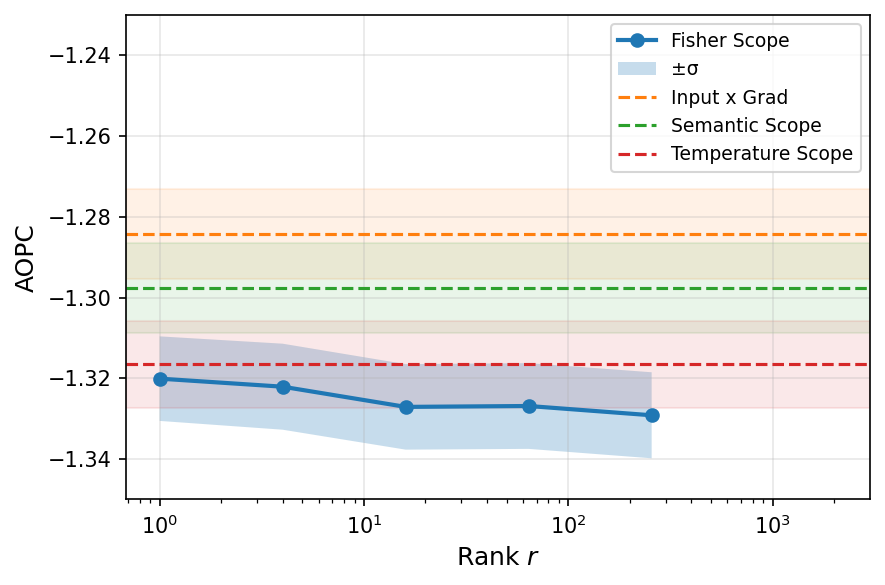

In [58]:
import re
import numpy as np
import matplotlib.pyplot as plt

_, numeric_table = table_generator(model_name, dataset_names)

# Split methods into ranked (Fisher) and rank-free baselines
fisher_mask = np.array([bool(re.search(r"k(\d+)$", m)) for m in numeric_table.index])
baseline_methods = numeric_table.index[~fisher_mask]
fisher_methods   = numeric_table.index[fisher_mask]

ranks = np.array([int(re.search(r"k(\d+)$", m).group(1)) for m in fisher_methods])
sort_idx = np.argsort(ranks)
ranks = ranks[sort_idx]
fisher_methods_sorted = fisher_methods[sort_idx]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

# --- Fisher Scope: line + shaded SEM band ---
for dataset_name in dataset_names:
    aupc_sem  = np.array(numeric_table.loc[fisher_methods_sorted, dataset_name].tolist())
    aupc_vals = np.array([v[0] if v[0] is not None else np.nan for v in aupc_sem])
    sem_vals  = np.array([v[1] if v[1] is not None else 0.0      for v in aupc_sem])

    ax.plot(ranks, aupc_vals, marker="o", linewidth=2, label=f"Fisher Scope")
    ax.fill_between(ranks, aupc_vals - sem_vals, aupc_vals + sem_vals, alpha=0.25, label = '±σ')

# --- Baselines: one horizontal dashed line per method ---
baseline_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
x_lim = (ranks[0] * 0.6, ranks[-1] * 1.6)
for i, method in enumerate(baseline_methods):
    color = baseline_colors[(i + len(dataset_names)) % len(baseline_colors)]
    for dataset_name in dataset_names:
        aupc, sem = numeric_table.loc[method, dataset_name]
        if aupc is None:
            continue
        ax.axhline(aupc, linestyle="--", linewidth=1.5, color=color, label=method)
        if sem:
            ax.axhspan(aupc - sem, aupc + sem, alpha=0.10, color=color)

ax.set_xscale("log")
# ax.set_xticks(ranks)

ax.set_xlabel("Rank $r$", fontsize=12)
ax.set_ylabel("AOPC", fontsize=12)
ax.set_xlim(0.683, 2998.4)
ax.set_ylim(-1.35, -1.23)
ax.legend(fontsize=9, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()